We use scipy.signal.stft to perform the heavy lifting. Here is a breakdown of the parameters you need to understand:  
- nperseg (Window Size): How many samples we look at at once. $1024$ or $2048$ is standard for speech.
- noverlap: To keep the audio smooth, we overlap the windows (usually by $50\%$ or $75\%$).
- The Output: It gives you three things: F (Frequencies), T (Time steps), and Zxx (The complex "map" of your audio).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

def implement_stft(filename):
    # 1. Load the file
    fs, data = wavfile.read(filename)
    if len(data.shape) > 1: data = data[:, 0] # Mono only

    # 2. Perform STFT
    # f = frequency array, t = time array, Zxx = STFT of data
    f, t, Zxx = signal.stft(data, fs, nperseg=1024, noverlap=512)

    # 3. Convert to Magnitude (dB)
    # We take the absolute value of the complex numbers
    # and convert to a log scale for human hearing
    amp = np.abs(Zxx)
    amp_db = 10 * np.log10(amp**2 + 1e-10) # 1e-10 prevents log(0) errors

    # 4. Visualization
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t, f, amp_db, shading='gouraud', cmap='magma')
    plt.title(f'STFT Magnitude Spectrogram: {filename}')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.colorbar(label='Intensity [dB]')
    plt.ylim(0, 8000) # Zoom into the speech range
    plt.show()

    return f, t, Zxx

# usage: f, t, Zxx = implement_stft('audio_1.wav')

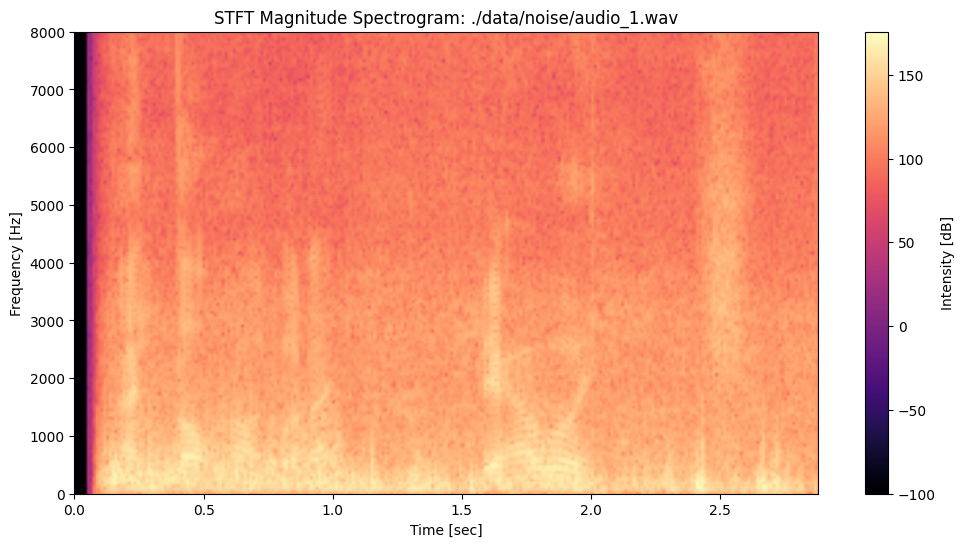

In [4]:
input_file = "./data/noise/audio_1.wav"
f, t, Zxx = implement_stft(input_file)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

def visualize_stft_grid(filename):
    fs, data = wavfile.read(filename)
    if len(data.shape) > 1: data = data[:, 0]

    # Compute STFT
    f, t, Zxx = signal.stft(data, fs, nperseg=1024)
    
    # We use the Magnitude (absolute value) for visualization
    magnitude = np.abs(Zxx)

    # Plotting
    plt.figure(figsize=(10, 6))
    
    # We use a log scale (dB) because the raw numbers are often too spread out to see
    plt.pcolormesh(t, f, 10 * np.log10(magnitude + 1e-10), shading='gouraud', cmap='viridis')
    
    plt.title('STFT: The Time-Frequency Grid')
    plt.ylabel('Frequency [Hz] (Which note?)')
    plt.xlabel('Time [sec] (When?)')
    plt.colorbar(label='Volume [dB] (How loud?)')
    plt.ylim(0, 5000) # Focus on the speech area
    plt.show()

# visualize_stft_grid('your_audio.wav')

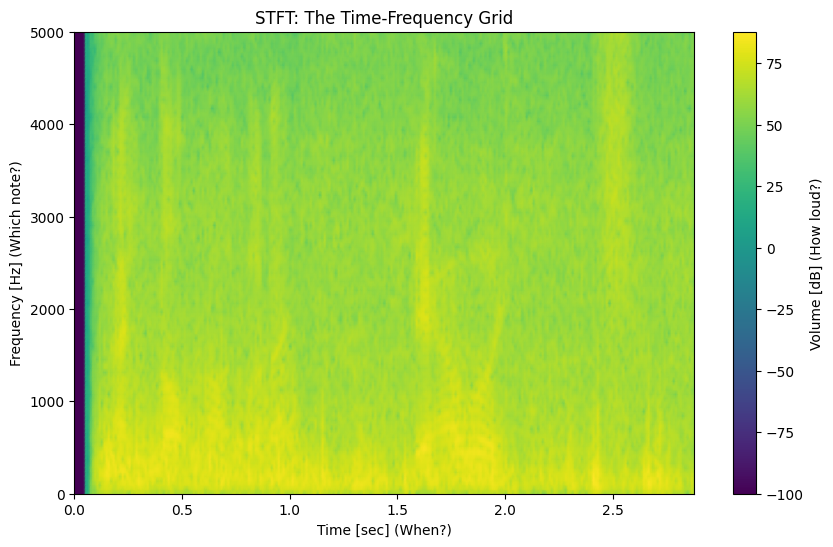

In [6]:
input_file = "./data/noise/audio_1.wav"
visualize_stft_grid(input_file)

denoise

In [7]:
import numpy as np
from scipy import signal
from scipy.io import wavfile

def denoise_audio(filename, output_name):
    # 1. Load and perform STFT
    fs, data = wavfile.read(filename)
    if len(data.shape) > 1: data = data[:, 0]
    
    f, t, Zxx = signal.stft(data, fs, nperseg=1024)
    
    # 2. Get Noise Profile (using the first 10 frames as silence)
    # We calculate the mean magnitude of the noise
    noise_mag = np.mean(np.abs(Zxx[:, :10]), axis=1, keepdims=True)
    
    # 3. Spectral Subtraction
    # Subtract noise magnitude from the signal magnitude
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)
    
    # Calculate the Signal-to-Noise Ratio (SNR) per frequency bin
    # We add a tiny epsilon (1e-8) to avoid division by zero
    snr = mag / (noise_mag + 1e-8)
    
    # Create a mask: 1 means keep everything, 0 means silence
    # We use a floor of 0.1 (10%) so the noise doesn't "pop" in and out
    mask = np.maximum(1 - (1.0 / (snr + 1e-8)), 0.1) 
    
    # Apply the mask to the original magnitude
    cleaned_mag = mag * mask
    
    # 4. Reconstruct the complex signal (Clean Mag + Original Phase)
    Zxx_clean = cleaned_mag * np.exp(1j * phase)
    
    # 5. Inverse STFT to get back to Time Domain
    _, clean_audio = signal.istft(Zxx_clean, fs, nperseg=1024)
    
    # --- NEW: NORMALIZATION STEP ---
    # 1. Convert to float32 first for safety
    clean_audio = clean_audio.astype(np.float32)
    
    # 2. Peak normalization: Scale so the loudest part is 1.0
    if np.max(np.abs(clean_audio)) > 0:
        clean_audio = clean_audio / np.max(np.abs(clean_audio))
    
    # 3. Scale to the int16 range (32767) and convert
    clean_audio_int16 = (clean_audio * 32767).astype(np.int16)
    # -------------------------------

    # Save the result
    wavfile.write(output_name, fs, clean_audio_int16)

# Usage
# denoise_audio('noisy_audio.wav', 'cleaned_audio.wav')

In [8]:
input_file = "./data/noise/audio_4.wav"
output = "output_audio.wav"
denoise_audio(input_file, output)

In [13]:
import librosa
import soundfile as sf
from scipy.signal import medfilt

def denoise_audio_librosa(filename, output_name):
    # 1. Load audio (librosa automatically converts to float and handles mono)
    y, sr = librosa.load(filename, sr=None)
    
    # 2. Compute STFT
    s_full, phase = librosa.magphase(librosa.stft(y))
    
    noise_power = np.mean(s_full[:, :int(sr * 0.1)], axis=1)

    mask = s_full > noise_power[:, None]

    mask = mask.astype(float)
    mask = medfilt(mask, kernel_size=(1,5))
    s_clean = s_full * mask
    y_clean = librosa.istft(s_clean * phase)

   
    sf.write(output_name, y_clean, sr)

In [18]:
input_file = "./data/noise/audio_3.wav"
output = "output_audio.wav"
denoise_audio_librosa(input_file, output)